## Imports

In [2]:
# Kaggle notebook setup
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import os
from pathlib import Path
import torch
import torchvision
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from transformers import AutoTokenizer
from sklearn.model_selection import train_test_split
import torch.nn as nn
from transformers import AutoModel
from torchvision.models import resnet50
import torch.optim as optim
from tqdm import tqdm 
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

## Download data

In [3]:
# Explore the dataset structure
data_path = "./CrisisMMD_v2.0/"

# Download dataset
! gdown 1wi_kAVETQHQyGA-thBhP7VY1L2jD5quI

# Unzip
! tar -xzf "CrisisMMD_v2.0.tar.gz"

# List all disaster events
annotation_files = os.listdir(f"{data_path}annotations/")
print("Disaster events:", annotation_files)

# Load first annotation file to understand structure
sample_annotations = pd.read_csv(f"{data_path}annotations/{annotation_files[0]}", sep='\t')
print("Dataset shape:", sample_annotations.shape)
print("Columns:", sample_annotations.columns.tolist())
sample_annotations.head()

Downloading...
From (original): https://drive.google.com/uc?id=1wi_kAVETQHQyGA-thBhP7VY1L2jD5quI
From (redirected): https://drive.google.com/uc?id=1wi_kAVETQHQyGA-thBhP7VY1L2jD5quI&confirm=t&uuid=3b4277df-749e-42de-b7f6-fcf9061cf0dd
To: /content/CrisisMMD_v2.0.tar.gz
100% 1.90G/1.90G [00:25<00:00, 73.7MB/s]
Disaster events: ['california_wildfires_final_data.tsv', '._california_wildfires_final_data.tsv', 'mexico_earthquake_final_data.tsv', 'srilanka_floods_final_data.tsv', 'hurricane_maria_final_data.tsv', '._hurricane_irma_final_data.tsv', '._hurricane_maria_final_data.tsv', '._srilanka_floods_final_data.tsv', 'iraq_iran_earthquake_final_data.tsv', 'hurricane_irma_final_data.tsv', 'hurricane_harvey_final_data.tsv']
Dataset shape: (1589, 15)
Columns: ['tweet_id', 'image_id', 'text_info', 'text_info_conf', 'image_info', 'image_info_conf', 'text_human', 'text_human_conf', 'image_human', 'image_human_conf', 'image_damage', 'image_damage_conf', 'tweet_text', 'image_url', 'image_path']


,tweet_id,image_id,text_info,text_info_conf,image_info,image_info_conf,text_human,text_human_conf,image_human,image_human_conf,image_damage,image_damage_conf,tweet_text,image_url,image_path
0,917791044158185473,917791044158185473_0,informative,1.0000,informative,0.6766,other_relevant_information,1.0000,other_relevant_information,0.6766,NaN,NaN,RT @Gizmodo: Wildfires raging through Northern...,http://pbs.twimg.com/media/DLyi_WYVYAApwNg.jpg,data_image/california_wildfires/10_10_2017/917...
1,917791130590183424,917791130590183424_0,informative,1.0000,informative,0.6667,infrastructure_and_utility_damage,1.0000,affected_individuals,0.6667,NaN,NaN,PHOTOS: Deadly wildfires rage in California ht...,http://pbs.twimg.com/media/DLymKm9UMAAu0qw.jpg,data_image/california_wildfires/10_10_2017/917...
2,917791291823591425,917791291823591425_0,informative,0.6813,informative,1.0000,other_relevant_information,0.6813,infrastructure_and_utility_damage,1.0000,severe_damage,1.0,RT @Cal_OES: PLS SHARE: Weâ€™re capturing wild...,http://pbs.twimg.com/media/DLudaaZV4AAjT7x.jpg,data_image/california_wildfires/10_10_2017/917...
3,917791291823591425,917791291823591425_1,informative,0.6813,not_informative,1.0000,other_relevant_information,0.6813,not_humanitarian,1.0000,NaN,NaN,RT @Cal_OES: PLS SHARE: Weâ€™re capturing wild...,http://pbs.twimg.com/media/DLudaZXUMAABAEZ.jpg,data_image/california_wildfires/10_10_2017/917...
4,917792092100988929,917792092100988929_0,informative,0.6727,informative,0.6612,other_relevant_information,0.6727,infrastructure_and_utility_damage,0.6612,severe_damage,1.0,RT @TIME: California's raging wildfires as you...,http://pbs.twimg.com/media/DLwNe-NXUAE0XCw.jpg,data_image/california_wildfires/10_10_2017/917...


## Gather all data in "dataset"

In [4]:
# Analyze all disaster events and create unified dataset
def load_all_annotations():
    all_data = []
    disaster_events = []
    
    for file in annotation_files:
        if file.endswith('.tsv'):
            event_name = file.replace('.tsv', '')
            df = pd.read_csv(f"{data_path}annotations/{file}", sep='\t', encoding='latin1')
            df['disaster_event'] = event_name
            all_data.append(df)
            disaster_events.append(event_name)
            
    combined_df = pd.concat(all_data, ignore_index=True)
    return combined_df, disaster_events

combined_data, events = load_all_annotations()

In [5]:
dataset = combined_data[["tweet_id","image_id","text_info","image_info", "tweet_text","image_path"]]
dataset.head()
dataset['text_label'] = dataset['text_info'].apply(lambda x: 1 if x == 'informative' else 0)
dataset['image_label'] = dataset['image_info'].apply(lambda x: 1 if x == 'informative' else 0)
dataset['final_fusion_label'] = ((dataset['text_label'] == 1) | (dataset['image_label'] == 1)).astype(int)
dataset['final_fusion_label'].value_counts()

#final_fusion_label_counts 13784 / 4298

,count
final_fusion_label,
1,13784
0,4298


Note the class imbalance

## Dataset Class text + image

In [6]:
class MultimodalCrisisDataset(Dataset):
    def __init__(self, dataframe, base_image_dir, tokenizer, image_transform=None, max_length=128):
        """
        Args:
            dataframe: Pandas DataFrame containing text, image paths, and labels.
            base_image_dir: Root directory for images.
            tokenizer: Hugging Face tokenizer for DistilBERT.
            image_transform: PyTorch transforms for ResNet.
            max_length: Max token length for the text.
        """
        self.dataframe = dataframe.reset_index(drop=True)
        self.base_image_dir = base_image_dir
        self.tokenizer = tokenizer
        self.image_transform = image_transform
        self.max_length = max_length

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = os.path.join(self.base_image_dir, self.dataframe.loc[idx, 'image_path'])
        try:
            image = Image.open(img_path).convert('RGB')
        except Exception:
            # Fallback for missing/corrupted images to prevent crashes
            image = Image.new('RGB', (224, 224)) 
            
        if self.image_transform:
            image = self.image_transform(image)

        text = str(self.dataframe.loc[idx, 'tweet_text'])
        
        # Tokenize the text (converts words to math tensors)
        encoded_text = self.tokenizer(
            text,
            padding='max_length',
            truncation=True,
            max_length=self.max_length,
            return_tensors='pt' # Return PyTorch tensors
        )

        # This should be your final OR logic label (1 if either text or image is informative, else 0)
        label = self.dataframe.loc[idx, 'final_fusion_label']

        # Return a dictionary containing all the necessary pieces
        return {
            'input_ids': encoded_text['input_ids'].squeeze(0),       # Text Math
            'attention_mask': encoded_text['attention_mask'].squeeze(0), # Text Mask
            'image': image,                                          # Image Math
            'label': torch.tensor(label, dtype=torch.long)           # Target Answer
        }

## Dataloaders

In [7]:
# 1. The DistilBERT Tokenizer
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

# 2. The ResNet Image Transforms (Testing version, no chaotic augmentation needed for the frozen body)
image_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Split the unified dataframe (Ensure you use the same random_state as before!)
train_df, test_df = train_test_split(dataset, test_size=0.2, random_state=42)

BASE_IMG_DIR = "./CrisisMMD_v2.0/data_image/"

# Create the Datasets
train_dataset = MultimodalCrisisDataset(train_df, BASE_IMG_DIR, tokenizer, image_transforms)
test_dataset = MultimodalCrisisDataset(test_df, BASE_IMG_DIR, tokenizer, image_transforms)

# Create the DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# --- Quick Test ---
batch = next(iter(train_loader))
print("Multimodal Batch Loaded Successfully!")
print(f"Images Shape: {batch['image'].shape}")               # Should be [32, 3, 224, 224]
print(f"Input IDs Shape: {batch['input_ids'].shape}")         # Should be [32, 128]
print(f"Labels Shape: {batch['label'].shape}")               # Should be [32]

Multimodal Batch Loaded Successfully!
Images Shape: torch.Size([32, 3, 224, 224])
Input IDs Shape: torch.Size([32, 128])
Labels Shape: torch.Size([32])


## Model with fusion layer

In [8]:
class MultimodalFusionNetwork(nn.Module):
    def __init__(self, saved_text_dir, saved_vision_path):
        super(MultimodalFusionNetwork, self).__init__()

        # AutoModel will automatically strip the 2-class head for you!
        self.text_extractor = AutoModel.from_pretrained(saved_text_dir)

        # Freeze it
        for param in self.text_extractor.parameters():
            param.requires_grad = False
        
        # Step A: Load the blank architecture (Defaults to 1000 classes)
        self.vision_extractor = resnet50(weights=None)
        
        # Step B: Bolt on the 2-class head SO THE SHAPES MATCH the saved .pth file
        self.vision_extractor.fc = nn.Linear(2048, 2)
        
        # Step C: NOW you can safely load the weights! 
        self.vision_extractor.load_state_dict(torch.load(saved_vision_path))
        
        # Step D: THE AMPUTATION: Strip the head and replace with Identity
        self.vision_extractor.fc = nn.Identity()
        
        # Step E: Freeze the vision model 
        for param in self.vision_extractor.parameters():
            param.requires_grad = False

        # Text (768) + Vision (2048) = 2816 combined features
        self.fusion_classifier = nn.Sequential(
            nn.Linear(2816, 512),
            nn.ReLU(),
            nn.Dropout(p=0.5), # Crucial to prevent overfitting!
            nn.Linear(512, 2)  # Final Output: Safe (0) vs Disaster (1)
        )

    def forward(self, input_ids, attention_mask, images):
        # 1. Get the 768-D Text Vector
        # We grab the "CLS" token (index 0) which holds the summary of the whole tweet
        text_output = self.text_extractor(input_ids=input_ids, attention_mask=attention_mask)
        context_vector = text_output.last_hidden_state[:, 0, :] 
        
        # 2. Get the 2048-D Image Vector
        evidence_vector = self.vision_extractor(images)
        
        # 3. Concatenate them side-by-side
        # shape becomes [batch_size, 2816]
        combined_vectors = torch.cat((context_vector, evidence_vector), dim=1)
        
        # 4. Make the final decision
        final_prediction = self.fusion_classifier(combined_vectors)
        
        return final_prediction

## Training

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = MultimodalFusionNetwork(
    saved_text_dir="/content/drive/My Drive/text_branch" , 
    saved_vision_path="/content/drive/My Drive/vision_brain.pth"
).to(device)


# Try to compensate for the class imbalance by giving more weight to the minority class (the safe tweets)
# ==============================================================================================
count_safe_0 = 4298
count_disaster_1 = 13784
total_samples = count_safe_0 + count_disaster_1

# Calculate the inverse weights (the rarer the class, the higher the weight)
weight_safe_0 = total_samples / count_safe_0       # roughly 4.2
weight_disaster_1 = total_samples / count_disaster_1   # roughly 1.3

class_weights = torch.tensor([weight_safe_0, weight_disaster_1], dtype=torch.float).to(device)
# ==============================================================================================



# Give the weights to your Loss Function!
criterion = nn.CrossEntropyLoss(weight=class_weights)

# CRITICAL: We are ONLY passing the tiny fusion_classifier to the optimizer.
# DistilBERT and ResNet are completely locked, meaning this will train lightning fast.
optimizer = optim.Adam(model.fusion_classifier.parameters(), lr=1e-3)

# Add our Learning Rate Scheduler to dial in precision in the later epochs
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)

EPOCHS = 10

print("Starting Late Fusion Training...")

for epoch in range(EPOCHS):
    model.train() 
    running_loss = 0.0
    correct = 0
    total = 0
    
    # Progress bar setup
    loop = tqdm(train_loader, leave=True)
    
    for batch in loop:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        images = batch['image'].to(device)
        labels = batch['label'].to(device)
        
        optimizer.zero_grad()
        
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, images=images)
        
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        # Step F: Track Statistics
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        # Update progress bar visuals
        loop.set_description(f"Epoch [{epoch+1}/{EPOCHS}]")
        loop.set_postfix(loss=loss.item(), acc=100.*correct/total)
        
    # Lower the learning rate at the end of the epoch if needed
    scheduler.step()

print("\nMultimodal Fusion Training Complete!")

# Save the final, unified brain
torch.save(model.state_dict(), "ultimate_multimodal_brain.pth")

Using device: cuda


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: /content/drive/My Drive/text_branch
Key                   | Status     |  | 
----------------------+------------+--+-
pre_classifier.weight | UNEXPECTED |  | 
classifier.weight     | UNEXPECTED |  | 
pre_classifier.bias   | UNEXPECTED |  | 
classifier.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Starting Late Fusion Training...


Epoch [10/10]: 100%|██████████| 453/453 [02:20<00:00,  3.23it/s, acc=79.8, loss=0.193]



Multimodal Fusion Training Complete!


## Test final model

Starting evaluation on the unseen Test Set...
Evaluation complete!

--- ULTIMATE MULTIMODAL FUSION RESULTS ---
Test Accuracy: 81.97%
Test F1 Score: 0.8764


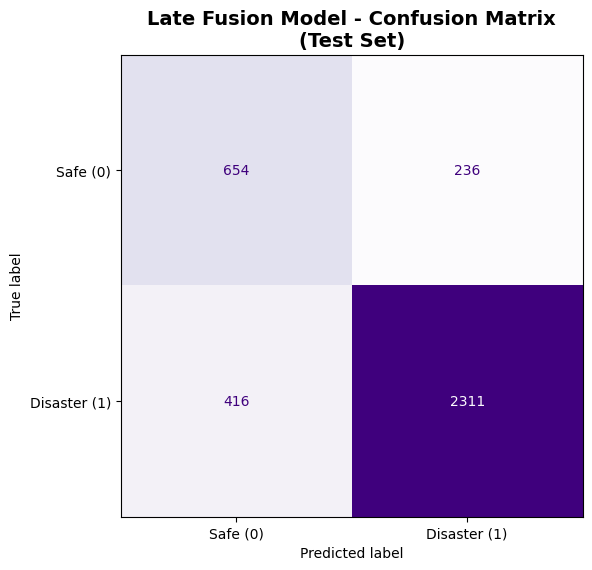

In [10]:
# Turn off training layers (like Dropout) to ensure stable, reliable predictions
model.eval()

all_predictions = []
all_true_labels = []

print("Starting evaluation on the unseen Test Set...")

# torch.no_grad() disables learning math, saving RAM and speeding up inference
with torch.no_grad():
    for batch in test_loader:
        # Step A: Unpack the Multimodal Dictionary
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        images = batch['image'].to(device)
        labels = batch['label'].to(device)
        
        # Step B: Have the Fusion Model guess
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, images=images)
        
        # Step C: Get the highest probability class
        _, predicted_classes = torch.max(outputs, dim=1)
        
        # Step D: Save the results to CPU lists for sklearn
        all_predictions.extend(predicted_classes.cpu().numpy())
        all_true_labels.extend(labels.cpu().numpy())

print("Evaluation complete!")

# Calculate standard metrics
accuracy = accuracy_score(all_true_labels, all_predictions)
f1 = f1_score(all_true_labels, all_predictions, average='binary')

print(f"\n--- ULTIMATE MULTIMODAL FUSION RESULTS ---")
print(f"Test Accuracy: {accuracy * 100:.2f}%")
print(f"Test F1 Score: {f1:.4f}")

# Generate the Confusion Matrix
cm = confusion_matrix(all_true_labels, all_predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Safe (0)", "Disaster (1)"])

# Plotting
fig, ax = plt.subplots(figsize=(6, 6))
# Using 'Purples' as a fun nod to combining Teammate 1's Text (Blues) and Teammate 2's Vision (Reds)!
disp.plot(cmap='Purples', ax=ax, colorbar=False) 
plt.title('Late Fusion Model - Confusion Matrix\n(Test Set)', fontsize=14, fontweight='bold')
plt.grid(False) 
plt.show()

## Save weights to Google Drive

In [11]:
from google.colab import drive
import shutil

# This will prompt you to click a link and log in to your Google account
drive.mount('/content/drive')

# Copy the model from Colab's temporary storage to your permanent Drive
source_file = "ultimate_multimodal_brain.pth"

# Change "My Drive" to a specific folder path if you want!
destination_file = "/content/drive/My Drive/ultimate_multimodal_brain.pth" 

shutil.copy(source_file, destination_file)
print("Model safely backed up to Google Drive!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model safely backed up to Google Drive!
